# Sınıflandırma Genel

Bu notebookta 3. bölümde gördüğümüz tüm konuların üzerinden tekrardan geçecek ve bazı konularda ileri düzey yaklaşım tarzları öğreneceğiz. O zaman hadi başlayalım :)

## 1. Veri Setini Yükleme ve Anlama

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style

from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error, r2_score

Bu çalışmada elimizde 2 farklı veri seti var. Biri modelimizi oluşturmak için kullanacağımız `train.csv`, diğeri ise modelimizi test etmek için kullanacağımız `test.csv`. Hadi bunları biraz inceleyelim.

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


> **SORU:** Train veri setimizde 11 tane, test veri setimizde 10 tane sütunumuz var. Test veri setimizde hangi sütun yok? Neden bu sütuna ilişkin herhangi bir bilgi verilmemiş olabilir?

Çalışmaya başlamadan önce veri setimizi biraz daha yakından tanıyalım.

In [5]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Veri setinde bazı anlamlandıramadığımız değerler var gibi duruyor. Örneğin `Pclass` sütunundaki sayısal değerler ne ifade ediyor? O yüzden devam etmeden önce, titanic veri setimizin içeriğini biraz daha iyi anlayalım.

[Metadata](https://www.kaggle.com/c/titanic)

In [6]:
train_df.columns.values

array(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype=object)

> **SORU:** Ve tabiki istatiksel değerler... Bu değerlere bakılınca verimizin dağılımı hakkında nasıl yorumlamalar yapabiliriz?

In [7]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Train veri setimize baktığımızda `Cabin`, `Age` ve `Embarked` sütunlarında bazı boş değerler olduğunu görüyorum. Veriyi analiz etmeye başlamadan önce ilk olarak bunlarla ilgilenelim.

In [8]:
total = train_df.isnull().sum().sort_values(ascending=False)
percent_1 = train_df.isnull().sum()/train_df.isnull().count()*100
percent_2 = (round(percent_1, 1)).sort_values(ascending=False)
missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
missing_data.head(12)

,Total,%
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2
PassengerId,0,0.0
Survived,0,0.0
Pclass,0,0.0
Name,0,0.0
Sex,0,0.0
SibSp,0,0.0
Parch,0,0.0


Tabiki, aynı şekilde test veri setimiz için de.

In [9]:
total = test_df.isnull().sum().sort_values(ascending=False)
percent_1 = test_df.isnull().sum()/test_df.isnull().count()*100
percent_2 = (round(percent_1, 1)).sort_values(ascending=False)
missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
missing_data.head(12)

,Total,%
Cabin,327,78.2
Age,86,20.6
Fare,1,0.2
PassengerId,0,0.0
Pclass,0,0.0
Name,0,0.0
Sex,0,0.0
SibSp,0,0.0
Parch,0,0.0
Ticket,0,0.0


## 2. Keşifsel Veri Analizi (EDA)

Veri setimizdeki boş değerlerle birazdan ilgilenicez. Ama öncesinde veri setimizin içeriğini biraz daha keşfedelim. İlk olarak bakalım yaşayan ve ölen kişilerle featurelarımız arasında net bir ilişki bulabilecek miyiz?

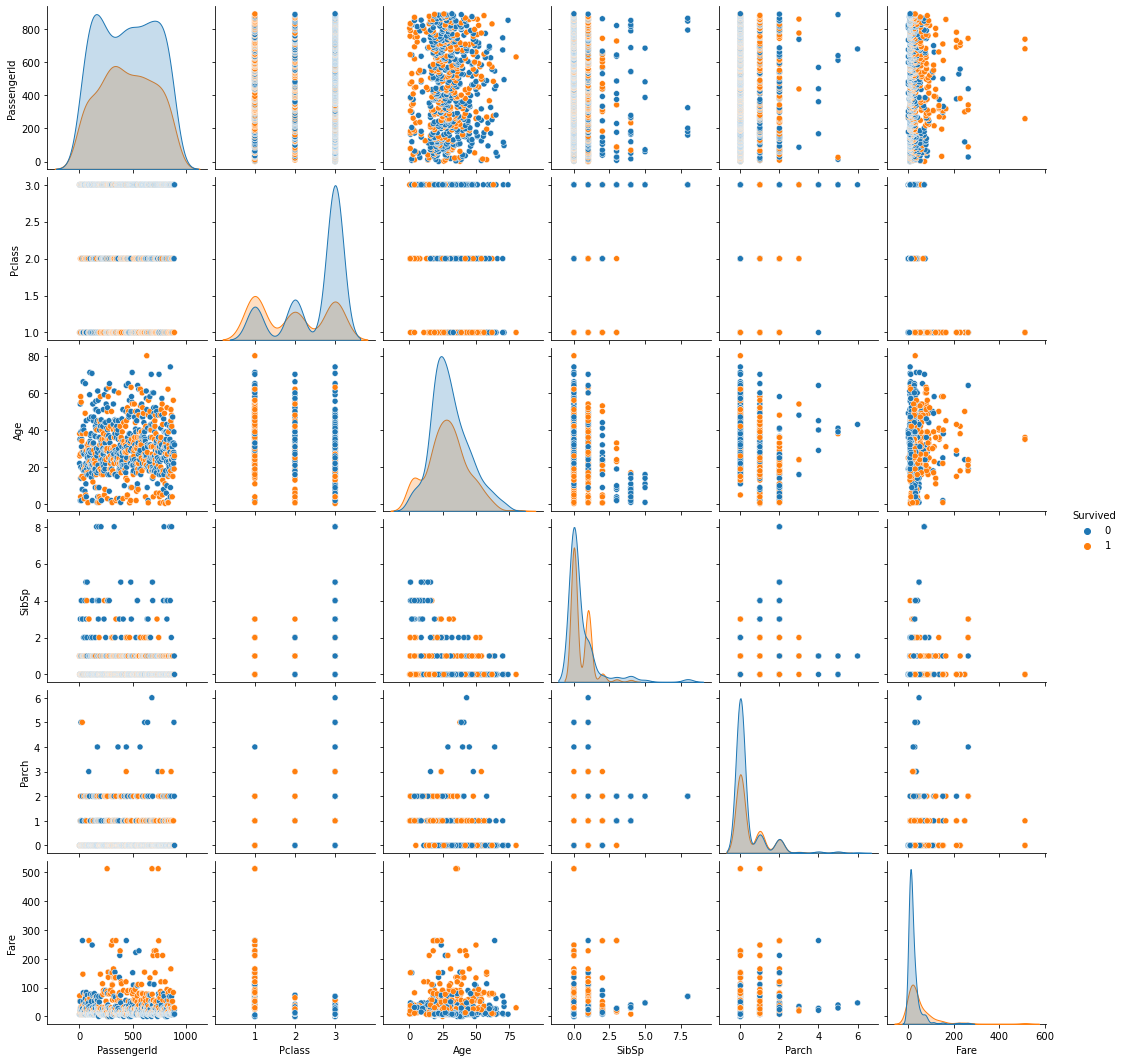

In [10]:
sns.pairplot(train_df, hue='Survived');

Kendi düşüncelerime göre böyle bir gemi kazasında, genellikle ilk olarak **bayanlar ve çocuklar** kurtarılmaya çalışılır. Peki bu durum gerçekte nasıl olmuş, şimdi de ona bakalım.

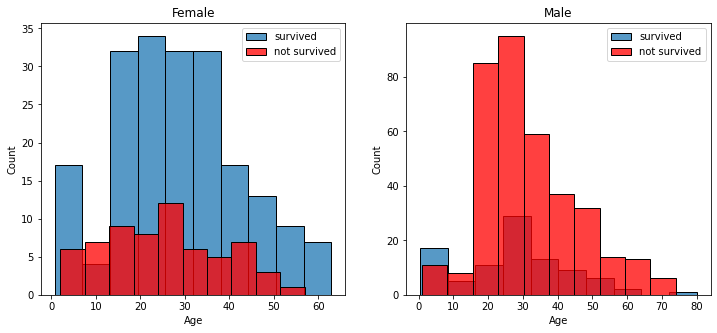

In [11]:
survived = 'survived'
not_survived = 'not survived'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=[12,5])
women = train_df[train_df['Sex']=='female']
men = train_df[train_df['Sex']=='male']
ax = sns.histplot(women[women['Survived']==1].Age.dropna(), bins=10, label = survived, ax = axes[0], kde =False)
ax = sns.histplot(women[women['Survived']==0].Age.dropna(), bins=10, label = not_survived, ax = axes[0], kde =False, color='red')
ax.legend()
ax.set_title('Female')
ax = sns.histplot(men[men['Survived']==1].Age.dropna(), bins=10, label = survived, ax = axes[1], kde = False)
ax = sns.histplot(men[men['Survived']==0].Age.dropna(), bins=10, label = not_survived, ax = axes[1], kde = False, color='red')
ax.legend()
ax.set_title('Male');

Verinin metadatasından elde ettiğimiz bilgiye göre, **Embarked** sütunu yolcunun gemiye nereden bindiği hakkında bir bilgi sağlıyordu. Bu değerlerin ne anlama geldiğine baktığımızda ise,

- **S = Southampton**
- **C = Cherbourg**
- **Q = Queenstown**

Şimdi de, bu sütunumuzla **Pclass** sütunundaki ilişkilere bakalım.

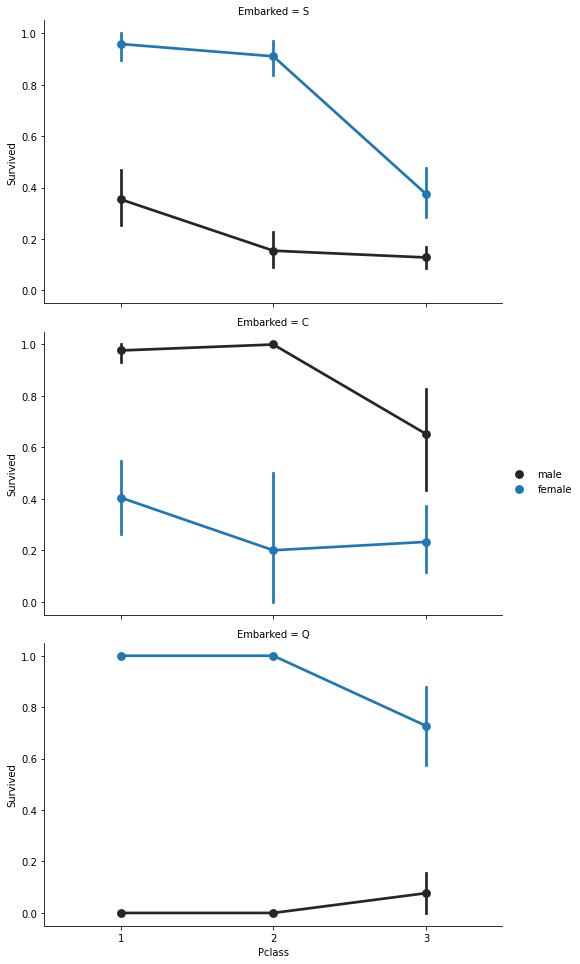

In [12]:
FacetGrid = sns.FacetGrid(train_df, row='Embarked', height=4.5, aspect=1.6)
FacetGrid.map(sns.pointplot, 'Pclass', 'Survived', 'Sex', hue_order=None, order=None)
FacetGrid.add_legend();

Satılan bilete ait olan sınıf bilgisi gerçekten de önemli gibi duruyor. Peki bunu doğrudan **Survived** sütunu ile ilişkilendirirsem?

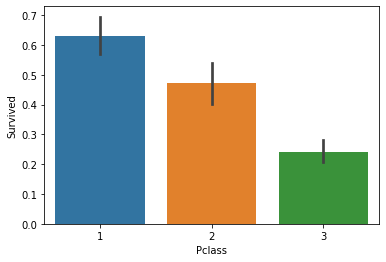

In [13]:
sns.barplot(x='Pclass', y='Survived', data=train_df);

## 3. Feature Engineering

Çalıştığımız veri seti hakkında ciddi anlamda bilgi sahibi olduk. Bu aşamada gerekli işlemleri yaparak ilk modelimizi de oluşturabilirdik. Ama şimdi gelin, modelimizi oluşturmaya başlamadan önce veriyle biraz oynayalım.

Düşüncelerime göre, bir yolcunun **yanlız olup olmaması** da önemli olan bir feature olabilir. Ama bu bilgi şu anda elimde yok, o zaman hadi biz üretelim :)

In [14]:
data = [train_df, test_df]
for dataset in data:
    dataset['Relatives'] = dataset['SibSp'] + dataset['Parch']
    dataset.loc[dataset['Relatives'] > 0, 'Alone'] = 0
    dataset.loc[dataset['Relatives'] == 0, 'Alone'] = 1
    dataset['Alone'] = dataset['Alone'].astype(int)
train_df['Alone'].value_counts()

1    537
0    354
Name: Alone, dtype: int64

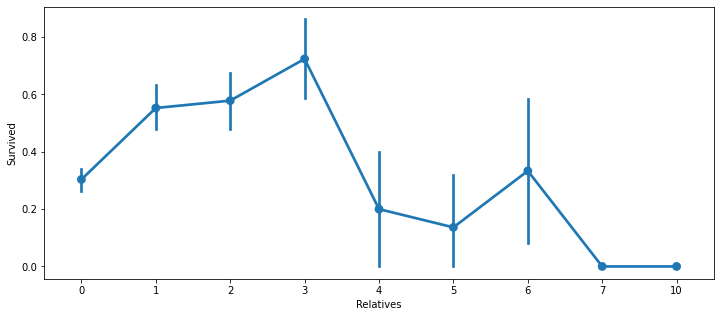

In [15]:
plt.figure(figsize=[12,5])
sns.pointplot(x='Relatives',y='Survived', data=train_df);

Özellikle yanında **en az 4 tane akrabası olan** yolcuların yaşama ihtimali ciddi oranda artıyor gibi gözüküyor. Bunu birazdan modelimizi geliştirirken kullanalım.

In [16]:
train_df = train_df.drop(['PassengerId'], axis=1)
test_df = test_df.drop(['PassengerId'], axis=1)

Hatırlarsanız **Cabin** sütunumuzda oldukça fazla boş değer vardı ve içerdiği bilgiye bakarsak o bilgiden doğrudan bir anlam çıkarmamız mümkün değil. Normalde şartlarda içerisinde bu kadar fazla boş veri barındıran bir sütunla çalışmamız pek mümkün olmaz. Ancak bir yandan da kişinin hangi kabinde seyahat ettiği, gelir seviyesiyle oldukça ilişkili olması lazım ve ben **bu bilgiyi kaybetmek istemiyorum**. Peki ben bunun için ne yapabilirim?

In [17]:
import re
deck = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "U": 8}
data = [train_df, test_df]

for dataset in data:
    dataset['Cabin'] = dataset['Cabin'].fillna("U")
    dataset['Deck'] = dataset['Cabin'].map(lambda x: re.compile("([a-zA-Z]+)").search(x).group()) # Regular Expression :)
    dataset['Deck'] = dataset['Deck'].map(deck)
    dataset['Deck'] = dataset['Deck'].fillna(0)
    dataset['Deck'] = dataset['Deck'].astype(int)
    
# İstediğim bilgiyi aldığıma göre Cabin sütunuyla vedalaşabilirim
train_df = train_df.drop(['Cabin'], axis=1)
test_df = test_df.drop(['Cabin'], axis=1)

**Age** sütununa baktığımda ise her 2 veri setimde de **yaklaşık %20 civarında** boş veri içerdiğini görüyorum.

> **SORU:** Peki bu boş değerleri ne yapalım?

In [18]:
data = [train_df, test_df]

for dataset in data:
    mean = train_df["Age"].mean()
    std = test_df["Age"].std()
    is_null = dataset["Age"].isnull().sum()
    # Standart sapmayı kullanarak rastgele integer değerler oluşturma
    rand_age = np.random.randint(mean - std, mean + std, size = is_null)
    # Boş değerlerimizi oluşturduğumuz rastgele integer değerlerle doldurma
    age_slice = dataset["Age"].copy()
    age_slice[np.isnan(age_slice)] = rand_age
    dataset["Age"] = age_slice
    dataset["Age"] = train_df["Age"].astype(int)
train_df["Age"].isnull().sum()

0

**Embarked** sütununda ise sadece 2 tane boş değerim vardı. Aslında bu 2 satırı direk kaldırabilirim, ancak elimde zaten kısıtlı miktarda veri var. Dolayısıyla hiçbir bilgiyi atlamak istemiyorum. Bunun için ilk olarak sütundaki değer dağılımlarına bakalım.

In [19]:
train_df['Embarked'].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

> **SORU:** Buradaki 2 tane boş değeri nasıl dolduralım?

In [20]:
common_value = 'S'
train_df['Embarked'] = train_df['Embarked'].fillna(common_value)

In [21]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Survived   891 non-null    int64  
 1   Pclass     891 non-null    int64  
 2   Name       891 non-null    object 
 3   Sex        891 non-null    object 
 4   Age        891 non-null    int64  
 5   SibSp      891 non-null    int64  
 6   Parch      891 non-null    int64  
 7   Ticket     891 non-null    object 
 8   Fare       891 non-null    float64
 9   Embarked   891 non-null    object 
 10  Relatives  891 non-null    int64  
 11  Alone      891 non-null    int64  
 12  Deck       891 non-null    int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 90.6+ KB


`train_df` veri setimizdeki boş değerlerden kurtulduk. Son olarak, `test_df` veri setimizdeki **Fare** sütunumuza da bakalım. Burada da sadece 1 tane boş değerimiz var. Peki ona ne yapabiliriz şimdi de onu inceleyelim.

In [22]:
test_df['Fare'].sort_values()

266      0.0000
372      0.0000
21       3.1708
133      6.4375
116      6.4375
         ...   
59     262.3750
53     263.0000
69     263.0000
343    512.3292
152         NaN
Name: Fare, Length: 418, dtype: float64

In [23]:
test_df.iloc[152]

Pclass                        3
Name         Storey, Mr. Thomas
Sex                        male
Age                          55
SibSp                         0
Parch                         0
Ticket                     3701
Fare                        NaN
Embarked                      S
Relatives                     0
Alone                         1
Deck                          8
Name: 152, dtype: object

Elimizde verdiği bilet ücreti bilinmeyen 55 yaşında erkek bir yolcu var. Ve bu yolcunun **Pclass** değeri 3 olarak gözüküyor. Verinin metadatasını incelerken edindiğimiz bilgiye göre `Pclass=3` olduğu durumlar, **kişinin sosyo-ekonomik durumunun zayıf olduğunu** gösteriyordu. Bu bilgiyi kullanarak bişeyler yapabiliriz.

In [24]:
test_df[test_df['Pclass'] == 3]

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Relatives,Alone,Deck
0,3,"Kelly, Mr. James",male,22,0,0,330911,7.8292,Q,0,1,8
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,38,1,0,363272,7.0000,S,1,0,8
3,3,"Wirz, Mr. Albert",male,35,0,0,315154,8.6625,S,0,1,8
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,35,1,1,3101298,12.2875,S,2,0,8
5,3,"Svensson, Mr. Johan Cervin",male,20,0,0,7538,9.2250,S,0,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...
412,3,"Henriksson, Miss. Jenny Lovisa",female,33,0,0,347086,7.7750,S,0,1,8
413,3,"Spector, Mr. Woolf",male,25,0,0,A.5. 3236,8.0500,S,0,1,8
415,3,"Saether, Mr. Simon Sivertsen",male,33,0,0,SOTON/O.Q. 3101262,7.2500,S,0,1,8
416,3,"Ware, Mr. Frederick",male,34,0,0,359309,8.0500,S,0,1,8


In [25]:
# 3. Pclass'a ait kişilerin ortalamasına bakalım ve ona göre boş değerimizi dolduralım
avg_fare = test_df[test_df['Pclass'] == 3]['Fare'].mean()
avg_fare

12.459677880184334

In [26]:
test_df['Fare'] = test_df['Fare'].fillna(avg_fare)
test_df['Fare'] = test_df['Fare'].astype(int)

In [27]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Pclass     418 non-null    int64 
 1   Name       418 non-null    object
 2   Sex        418 non-null    object
 3   Age        418 non-null    int64 
 4   SibSp      418 non-null    int64 
 5   Parch      418 non-null    int64 
 6   Ticket     418 non-null    object
 7   Fare       418 non-null    int64 
 8   Embarked   418 non-null    object
 9   Relatives  418 non-null    int64 
 10  Alone      418 non-null    int64 
 11  Deck       418 non-null    int64 
dtypes: int64(8), object(4)
memory usage: 39.3+ KB


Artık `test_df` veri setimizdeki boş değerlerden de kurtulduk. 

- Peki yapabileceklerimiz bu kadar mıydı? **Hayır!**

İyi veri bilimciler herkesin göremediklerini görebilenlerdir. Nasıl mı? Hadi bakalım.

Normal şartlarda kişinin ismi yani **Name** sütunu kişinin bu kazada ölüp ölmeyeceğiyle hiç ilgili değildir di mi?

- **Evet, bu doğru!** 

Ancak, **Name** sütununun içerisinde işime yarayabilecek bir bilgi var gibi gözüküyor :)

In [28]:
data = [train_df, test_df]
titles = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}

for dataset in data:
    # İnsanların isimlerinden başlıklarını alalım, bu bilgi işimize yarayabilir!
    dataset['Title'] = dataset.Name.str.extract('([A-Za-z]+)\.') # Regular Expression
    # Az sayıda olan başlıkları oluşturduğumuz Rare sütununa dahil edelim
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr',\
                                            'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    # Hatalı olan yazımları düzeltelim
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')
    # Sayısal değerlere dönüştürelim
    dataset['Title'] = dataset['Title'].map(titles)
    # Regular Expression kullanarak veri üretirken, garanti altına almak için boş değerlere de 0 atayalım
    dataset['Title'] = dataset['Title'].fillna(0)
train_df = train_df.drop(['Name'], axis=1)
test_df = test_df.drop(['Name'], axis=1)

In [29]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Survived   891 non-null    int64  
 1   Pclass     891 non-null    int64  
 2   Sex        891 non-null    object 
 3   Age        891 non-null    int64  
 4   SibSp      891 non-null    int64  
 5   Parch      891 non-null    int64  
 6   Ticket     891 non-null    object 
 7   Fare       891 non-null    float64
 8   Embarked   891 non-null    object 
 9   Relatives  891 non-null    int64  
 10  Alone      891 non-null    int64  
 11  Deck       891 non-null    int64  
 12  Title      891 non-null    int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 90.6+ KB


In [30]:
genders = {"male": 0, "female": 1}
data = [train_df, test_df]

for dataset in data:
    dataset['Sex'] = dataset['Sex'].map(genders)

In [31]:
train_df['Ticket'].describe()

count        891
unique       681
top       347082
freq           7
Name: Ticket, dtype: object

**Ticket** sütunuyla ilgili elimde kullanabileceğim hiçbir bilgi yok ve **çok fazla unique değer** var. Dolayısıyla, bu sütunumuzla vedalaşıyoruz.

In [32]:
train_df = train_df.drop(['Ticket'], axis=1)
test_df = test_df.drop(['Ticket'], axis=1)

In [33]:
ports = {"S": 0, "C": 1, "Q": 2}
data = [train_df, test_df]

for dataset in data:
    dataset['Embarked'] = dataset['Embarked'].map(ports)

In [34]:
train_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Relatives,Alone,Deck,Title
0,0,3,0,22,1,0,7.2500,0,1,0,8,1
1,1,1,1,38,1,0,71.2833,1,1,0,3,3
2,1,3,1,26,0,0,7.9250,0,0,1,8,2
3,1,1,1,35,1,0,53.1000,0,1,0,3,3
4,0,3,0,35,0,0,8.0500,0,0,1,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27,0,0,13.0000,0,0,1,8,5
887,1,1,1,19,0,0,30.0000,0,0,1,2,2
888,0,3,1,35,1,2,23.4500,0,3,0,8,2
889,1,1,0,26,0,0,30.0000,1,0,1,3,1


Elimizdeki, **Age** sütunumuzu da daha kullanılabilir bir hale getirelim.

In [35]:
data = [train_df, test_df]
for dataset in data:
    dataset['Age'] = dataset['Age'].astype(int)
    dataset.loc[dataset['Age'] <= 3, 'Age'] = 0 # Bebek
    dataset.loc[(dataset['Age'] > 3) & (dataset['Age'] <= 8), 'Age'] = 1 # Çocuk
    dataset.loc[(dataset['Age'] > 8) & (dataset['Age'] <= 18), 'Age'] = 2 # Ergen
    dataset.loc[(dataset['Age'] > 18) & (dataset['Age'] <= 30), 'Age'] = 3 # Genç
    dataset.loc[(dataset['Age'] > 30) & (dataset['Age'] <= 65), 'Age'] = 4 # Yetişkin
    dataset.loc[dataset['Age'] > 65, 'Age'] = 5 # Yaşlı

**Age** ve **Pclass** sütunlarını kullanarak elde edeceğimiz, **Age_Class** çarpanının belki modellerimize olumlu bir etkisi olabilir. Denemeden bilemeyiz :)

In [36]:
data = [train_df, test_df]
for dataset in data:
    dataset['Age_Class']= dataset['Age']* dataset['Pclass']

In [37]:
train_df.sort_values(by='Fare')

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Relatives,Alone,Deck,Title,Age_Class
271,1,3,0,3,0,0,0.0000,0,0,1,8,1,9
597,0,3,0,4,0,0,0.0000,0,0,1,8,1,12
302,0,3,0,3,0,0,0.0000,0,0,1,8,1,9
633,0,1,0,4,0,0,0.0000,0,0,1,8,1,4
277,0,2,0,4,0,0,0.0000,0,0,1,8,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,0,1,0,4,1,4,263.0000,0,5,0,3,1,4
341,1,1,1,3,3,2,263.0000,0,5,0,3,2,3
737,1,1,0,4,0,0,512.3292,1,0,1,2,1,4
258,1,1,1,4,0,0,512.3292,1,0,1,8,2,4


Görünen o ki, veri setimizde hiçbir bilet ücreti ödemeden gemiye biniş sağlayan yolcular var.

> **SORU:** Bu durum neden olmuş olabilir?

Sanırım, bu yolcuların bilet ücretleri **tanıdıkları başka kişiler tarafından** ödenmiş. Dolayısıyla, bu bilgiyi de veri setimize dahil edelim. Ama öncesinde **Fare** sütunumuzda değerleri de uygun bir şekilde gruplayalım.

In [38]:
for dataset in data:
    dataset['Fare_Per_Person'] = dataset['Fare']/(dataset['Relatives']+1)
    dataset['Fare_Per_Person'] = dataset['Fare_Per_Person'].astype(int)

train_df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Relatives,Alone,Deck,Title,Age_Class,Fare_Per_Person
0,0,3,0,3,1,0,7.2500,0,1,0,8,1,9,3
1,1,1,1,4,1,0,71.2833,1,1,0,3,3,4,35
2,1,3,1,3,0,0,7.9250,0,0,1,8,2,9,7
3,1,1,1,4,1,0,53.1000,0,1,0,3,3,4,26
4,0,3,0,4,0,0,8.0500,0,0,1,8,1,12,8
5,0,3,0,3,0,0,8.4583,2,0,1,8,1,9,8
6,0,1,0,4,0,0,51.8625,0,0,1,5,1,4,51
7,0,3,0,0,3,1,21.0750,0,4,0,8,4,0,4
8,1,3,1,3,0,2,11.1333,0,2,0,8,3,9,3
9,1,2,1,2,1,0,30.0708,1,1,0,8,3,4,15


In [39]:
data = [train_df, test_df]

for dataset in data:
    dataset.loc[ dataset['Fare'] <= 7.91, 'Fare'] = 0
    dataset.loc[(dataset['Fare'] > 7.91) & (dataset['Fare'] <= 14.454), 'Fare'] = 1
    dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31), 'Fare'] = 2
    dataset.loc[(dataset['Fare'] > 31) & (dataset['Fare'] <= 99), 'Fare'] = 3
    dataset.loc[(dataset['Fare'] > 99) & (dataset['Fare'] <= 250), 'Fare'] = 4
    dataset.loc[ dataset['Fare'] > 250, 'Fare'] = 5
    dataset['Fare'] = dataset['Fare'].astype(int)

In [40]:
train_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Relatives,Alone,Deck,Title,Age_Class,Fare_Per_Person
0,0,3,0,3,1,0,0,0,1,0,8,1,9,3
1,1,1,1,4,1,0,3,1,1,0,3,3,4,35
2,1,3,1,3,0,0,1,0,0,1,8,2,9,7
3,1,1,1,4,1,0,3,0,1,0,3,3,4,26
4,0,3,0,4,0,0,1,0,0,1,8,1,12,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,3,0,0,1,0,0,1,8,5,6,13
887,1,1,1,3,0,0,2,0,0,1,2,2,3,30
888,0,3,1,4,1,2,2,0,3,0,8,2,12,5
889,1,1,0,3,0,0,2,1,0,1,3,1,3,30


In [41]:
test_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Relatives,Alone,Deck,Title,Age_Class,Fare_Per_Person
0,3,0,3,0,0,0,2,0,1,8,1,9,7
1,3,1,4,1,0,0,0,1,0,8,3,12,3
2,2,0,3,0,0,1,2,0,1,8,1,6,9
3,3,0,4,0,0,1,0,0,1,8,1,12,8
4,3,1,4,1,1,1,0,2,0,8,3,12,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,3,0,3,0,0,1,0,0,1,8,1,9,8
414,1,1,4,0,0,4,1,0,1,3,5,4,108
415,3,0,4,0,0,0,0,0,1,8,1,12,7
416,3,0,4,0,0,1,0,0,1,8,1,12,8


## 4. Model Oluşturma

Veri setimizde şu ana kadar aklımıza gelen tüm işlemleri yaptığımıza göre, artık modellerimizi oluşturmaya başlayabiliriz.

In [42]:
X_train, X_test, Y_train, Y_test = train_test_split(train_df.iloc[:,1:], train_df['Survived'],
                                                    test_size = 0.2, random_state=42)

> **HATIRLATMA:** Burada hesaplanan değerlerin, modellerin **accuracy** değeri olduğunu unutmayın!

In [43]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train, Y_train)

Y_prediction = random_forest.predict(X_test)

acc_random_forest_train = round(random_forest.score(X_train, Y_train) * 100, 2)
acc_random_forest_test = round(random_forest.score(X_test, Y_test) * 100, 2)

In [44]:
logreg = LogisticRegression(solver='liblinear')
logreg.fit(X_train, Y_train)

Y_pred = logreg.predict(X_test)

acc_log_train = round(logreg.score(X_train, Y_train) * 100, 2)
acc_log_test = round(logreg.score(X_test, Y_test) * 100, 2)

In [45]:
knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)

Y_pred = knn.predict(X_test) 

acc_knn_train = round(knn.score(X_train, Y_train) * 100, 2)
acc_knn_test = round(knn.score(X_test, Y_test) * 100, 2)

In [46]:
gaussian = GaussianNB()
gaussian.fit(X_train, Y_train)  

Y_pred = gaussian.predict(X_test)  

acc_gaussian_train = round(gaussian.score(X_train, Y_train) * 100, 2)
acc_gaussian_test = round(gaussian.score(X_test, Y_test) * 100, 2)

In [47]:
perceptron = Perceptron()
perceptron.fit(X_train, Y_train)

Y_pred = perceptron.predict(X_test)

acc_perceptron_train = round(perceptron.score(X_train, Y_train) * 100, 2)
acc_perceptron_test = round(perceptron.score(X_test, Y_test) * 100, 2)

In [48]:
linear_svc = LinearSVC(dual=False)
linear_svc.fit(X_train, Y_train)

Y_pred = linear_svc.predict(X_test)

acc_linear_svc_train = round(linear_svc.score(X_train, Y_train) * 100, 2)
acc_linear_svc_test = round(linear_svc.score(X_test, Y_test) * 100, 2)

In [49]:
decision_tree = DecisionTreeClassifier() 
decision_tree.fit(X_train, Y_train) 

Y_pred = decision_tree.predict(X_test) 

acc_decision_tree_train = round(decision_tree.score(X_train, Y_train) * 100, 2)
acc_decision_tree_test = round(decision_tree.score(X_test, Y_test) * 100, 2)

> **HATIRLATMA:** **GridSearchCV** ve **RandomizedSearchCV** gibi yöntemlerini kullanarak en iyi parametreleri belirlemenizin, modellerinizin başarısını arttırabileceğini göz önünde bulundurun!

In [50]:
results = pd.DataFrame({
    'Model': ['Support Vector Machines', 'KNN', 'Logistic Regression', 
              'Random Forest', 'Naive Bayes', 'Perceptron', 'Decision Tree'],
    'Train Score': [acc_linear_svc_train, acc_knn_train, acc_log_train, acc_random_forest_train,
                   acc_gaussian_train, acc_perceptron_train, acc_decision_tree_train],
    'Test Score': [acc_linear_svc_test, acc_knn_test, acc_log_test, acc_random_forest_test,
                   acc_gaussian_test, acc_perceptron_test, acc_decision_tree_test]})

result_df = results.sort_values(by='Test Score', ascending=False)
result_df = result_df.set_index('Model')
result_df

,Train Score,Test Score
Model,,
Random Forest,94.52,83.24
Decision Tree,94.52,81.56
Support Vector Machines,81.60,78.21
Logistic Regression,81.74,78.21
KNN,83.43,77.09
Naive Bayes,77.25,74.30
Perceptron,41.99,44.69


Modellerimizin training scoreları ve test scoreları **Random Forest** ve **Decision Tree** algoritmaları dışında birbirine oldukça yakın çıkmış. Bu istediğimiz bir durum! Zamanla birçok sınıflandırma modeli oluştururken genellikle Karar Ağaçları'nın model başarısı olarak ön plana çıktığını göreceksiniz. Ancak bu algoritmalarda dikkat etmemiz gereken en önemli özelliklerinden biri, örneğimizde de gördüğümüz gibi **Overfitting'e** oldukça yatkın olmalarıdır.

Şimdi de, şu anda bize en başarılı model olarak gözüken algoritmamız olan **Random Forest**'daki sonuçları daha detaylı inceleyelim.

In [51]:
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier()
scores_accuracy = cross_val_score(rf, X_train, Y_train, cv=10, scoring = "accuracy")

print("Scores:", scores_accuracy)
print("Mean:", scores_accuracy.mean())
print("Standard Deviation:", scores_accuracy.std())

Scores: [0.79166667 0.81944444 0.78873239 0.87323944 0.87323944 0.8028169
 0.74647887 0.77464789 0.8028169  0.90140845]
Mean: 0.8174491392801253
Standard Deviation: 0.046972949349250726


In [52]:
scores_recall = cross_val_score(rf, X_train, Y_train, cv=10, scoring = "recall")

print("Scores:", scores_recall)
print("Mean:", scores_recall.mean())
print("Standard Deviation:", scores_recall.std())

Scores: [0.7037037  0.7037037  0.65384615 0.92307692 0.77777778 0.62962963
 0.7037037  0.62962963 0.62962963 0.85185185]
Mean: 0.7206552706552707
Standard Deviation: 0.09572490586795343


In [53]:
scores_precision = cross_val_score(rf, X_train, Y_train, cv=10, scoring = "precision")

print("Scores:", scores_precision)
print("Mean:", scores_precision.mean())
print("Standard Deviation:", scores_precision.std())

Scores: [0.76       0.79166667 0.73913043 0.8        0.82142857 0.85
 0.73076923 0.80952381 0.76       0.88461538]
Mean: 0.7947134097786271
Standard Deviation: 0.04658070136410597


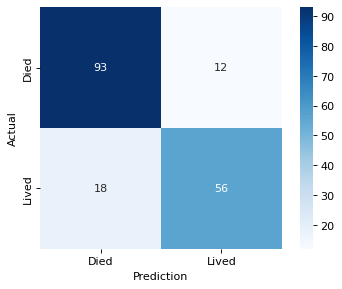

In [54]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

def make_confusion_matrix(model, threshold=0.5): # Ön tanımlı threshold değeri
    y_predict = (model.predict_proba(X_test)[:, 1] >= threshold)
    fraud_confusion = confusion_matrix(Y_test, y_predict)
    plt.figure(dpi=80)
    sns.heatmap(fraud_confusion, cmap=plt.cm.Blues, annot=True, square=True, fmt='d',
           xticklabels=['Died', 'Lived'],
           yticklabels=['Died', 'Lived']);
    plt.xlabel('Prediction')
    plt.ylabel('Actual')
    
make_confusion_matrix(random_forest) # En başarılı olan modelimiz

> **SORU:** Bu confusion matrix bize ne anlatıyor? Daha iyi confusion matrix oluşturmak için neler yapabilirdik?

In [55]:
from ipywidgets import interactive, FloatSlider

interactive(lambda threshold: make_confusion_matrix(random_forest, threshold), threshold=(0.0,1.0,0.02))

interactive(children=(FloatSlider(value=0.5, description='threshold', max=1.0, step=0.02), Output()), _dom_cla…

In [56]:
importances = pd.DataFrame({'Feature':X_train.columns,'Importance':np.round(random_forest.feature_importances_,3)})
importances = importances.sort_values('Importance',ascending=False).set_index('Feature')
importances.head(15)

,Importance
Feature,
Title,0.193
Sex,0.170
Fare_Per_Person,0.157
Age_Class,0.078
Deck,0.069
Fare,0.062
Pclass,0.061
Relatives,0.055
Embarked,0.047


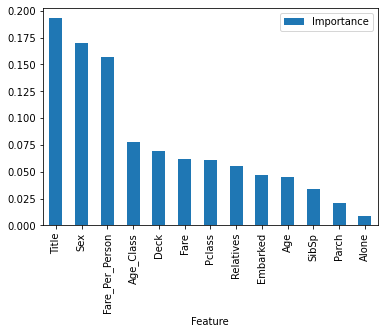

In [57]:
importances.plot.bar();

En ön plan çıkan özelliğe dikkat ettiniz mi? Bu bizim **yolcuların isim bilgilerinin içinden elde ettiğimiz bir bilgi!** İşte veriyi iyi işlemenin önemi :)

In [58]:
X_train  = X_train.drop(columns=["Alone","Parch"])
X_test  = X_test.drop(columns=["Alone","Parch"])

In [59]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train, Y_train)
Y_prediction = random_forest.predict(X_test)

acc_random_forest = round(random_forest.score(X_test, Y_test) * 100, 2)
print("Accuracy:", round(acc_random_forest,2), "%")

Accuracy: 83.24 %


Bu 2 tane özelliği modelimizden çıkardıktan sonra **Accuracy değerinde herhangi bir değişim olmadı**. Demek ki gerçekten de **Alone** ve **Parch** sütunlarına pek de ihtiyacımız yokmuş :)

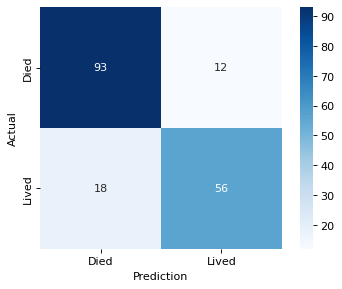

In [60]:
make_confusion_matrix(random_forest)

Son olarak da **Precision-Recall** ve **Roc Curve'lerde** yaşanan değişimleri inceleyelim.

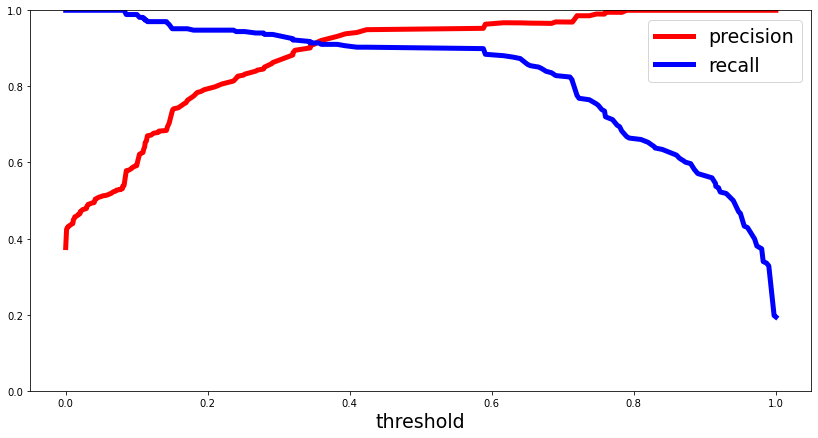

In [61]:
from sklearn.metrics import precision_recall_curve

y_scores = random_forest.predict_proba(X_train)
y_scores = y_scores[:,1]

precision, recall, threshold = precision_recall_curve(Y_train, y_scores)
def plot_precision_and_recall(precision, recall, threshold):
    plt.plot(threshold, precision[:-1], "r-", label="precision", linewidth=5)
    plt.plot(threshold, recall[:-1], "b", label="recall", linewidth=5)
    plt.xlabel("threshold", fontsize=19)
    plt.legend(loc="upper right", fontsize=19)
    plt.ylim([0, 1])

plt.figure(figsize=[14, 7])
plot_precision_and_recall(precision, recall, threshold)

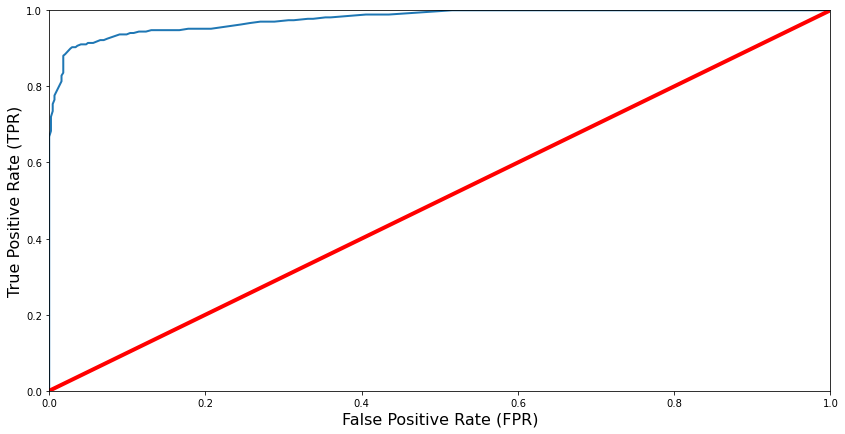

In [62]:
from sklearn.metrics import roc_curve

false_positive_rate, true_positive_rate, thresholds = roc_curve(Y_train, y_scores)

def plot_roc_curve(false_positive_rate, true_positive_rate, label=None):
    plt.plot(false_positive_rate, true_positive_rate, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'r', linewidth=4)
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate (FPR)', fontsize=16)
    plt.ylabel('True Positive Rate (TPR)', fontsize=16)

plt.figure(figsize=[14, 7])
plot_roc_curve(false_positive_rate, true_positive_rate)

In [63]:
from sklearn.metrics import roc_auc_score
r_a_score = roc_auc_score(Y_train, y_scores)
print("ROC-AUC-Score:", r_a_score)

ROC-AUC-Score: 0.9772673793196182


Artık son modelimize karar verdiğimize göre, bize verilen test veri seti üzerinde tahminlerimizi gerçekleştirelim.

In [64]:
test_df.drop(columns=["Alone","Parch"], inplace=True)

new_pred = random_forest.predict(test_df)

In [65]:
test_df["Prediction"] = new_pred # Yaptığımız tahminleri DataFrame'e ekleme
test_df["Prediction"] = test_df["Prediction"].apply(lambda x: str(x).replace("0","Died"))
test_df["Prediction"] = test_df["Prediction"].apply(lambda x: str(x).replace("1","Lived"))

In [66]:
test_df # Modelimizden elde ettiğimiz, test veri setindeki yolculara ilişkin tahminler :)

,Pclass,Sex,Age,SibSp,Fare,Embarked,Relatives,Deck,Title,Age_Class,Fare_Per_Person,Prediction
0,3,0,3,0,0,2,0,8,1,9,7,Died
1,3,1,4,1,0,0,1,8,3,12,3,Died
2,2,0,3,0,1,2,0,8,1,6,9,Died
3,3,0,4,0,1,0,0,8,1,12,8,Died
4,3,1,4,1,1,0,2,8,3,12,4,Died
...,...,...,...,...,...,...,...,...,...,...,...,...
413,3,0,3,0,1,0,0,8,1,9,8,Died
414,1,1,4,0,4,1,0,3,5,4,108,Lived
415,3,0,4,0,0,0,0,8,1,12,7,Died
416,3,0,4,0,1,0,0,8,1,12,8,Died
